In [22]:
from pathlib import Path
import json
import os
import shutil
import subprocess
import sys
import textwrap
import numpy as np
import pandas as pd
import matplotlib as plt
!pip install optuna

In [14]:
!pip install -q \
    "pandas>=2.0" \
    "numpy>=1.24" \
    "scikit-learn>=1.4" \
    "torch>=2.2" \
    "transformers>=4.40" \
    "optuna>=3.6" \
    "tqdm>=4.66" \
    "matplotlib>=3.8" \
    "seaborn>=0.13" \
    "tabulate>=0.9"

In [19]:
from sklearn.metrics import accuracy_score, cohen_kappa_score, matthews_corrcoef, precision_recall_fscore_support
from sklearn.model_selection import train_test_split
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoModelForSequenceClassification, AutoTokenizer, get_linear_schedule_with_warmup

In [7]:
import torch
import transformers
import optuna
import sklearn

print("torch:", torch.__version__)
print("transformers:", transformers.__version__)
print("optuna:", optuna.__version__)
print("sklearn:", sklearn.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

torch: 2.10.0+cu128
transformers: 5.0.0
optuna: 4.8.0
sklearn: 1.6.1
cuda available: True
gpu: Tesla T4


In [15]:
DATA_DIR = "/content"  #@param {type:"string"}
CLASSIFY_FILE = "classify_quality_combined.jsonl"  #@param {type:"string"}
SUMMARY_FILE = "triple_quality_summary.csv"  #@param {type:"string"}
OUTPUT_DIR = "/content/phase7_classification_outputs"  #@param {type:"string"}

DATA_DIR = Path(DATA_DIR)
CLASSIFY_PATH = DATA_DIR / CLASSIFY_FILE
SUMMARY_PATH = DATA_DIR / SUMMARY_FILE
OUTPUT_DIR = Path(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("CLASSIFY_PATH:", CLASSIFY_PATH, "exists=", CLASSIFY_PATH.exists())
print("SUMMARY_PATH:", SUMMARY_PATH, "exists=", SUMMARY_PATH.exists())
print("OUTPUT_DIR:", OUTPUT_DIR)

CLASSIFY_PATH: /content/classify_quality_combined.jsonl exists= True
SUMMARY_PATH: /content/triple_quality_summary.csv exists= True
OUTPUT_DIR: /content/phase7_classification_outputs


## Validate & Load Data

In [16]:
if not CLASSIFY_PATH.exists():
    raise FileNotFoundError(f"Missing training input file: {CLASSIFY_PATH}")

df = pd.read_json(CLASSIFY_PATH, lines=True)
df["id"] = df["id"].astype(str)

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Labels:", df["label"].nunique())
display(df[["id", "label", "n_triples", "avg_quality_score", "n_quality_high", "n_quality_low"]].head())

if SUMMARY_PATH.exists():
    quality_summary = pd.read_csv(SUMMARY_PATH)
    display(quality_summary)
else:
    print("No summary CSV found. Training can still run without it.")

Rows: 10000
Columns: 27
Labels: 21


,id,label,n_triples,avg_quality_score,n_quality_high,n_quality_low
0,2003.12367,hep-th,7,0.725019,1,6
1,2510.25987,astro-ph,10,0.768145,5,5
2,2305.17336,math,9,0.750784,3,6
3,2312.07368,cs,10,0.828268,9,1
4,1807.07975,quant-ph,14,0.729846,2,12


,split,n_documents,n_triples,avg_triples_per_doc,avg_quality_score,max_quality_score,avg_high_triples_per_doc,avg_low_triples_per_doc,zero_triple_documents,high_threshold
0,cluster,5000,33587,6.717400,0.769383,0.979671,3.4678,3.249600,74,0.75
1,classify,10000,68084,6.808400,0.768498,0.979671,3.4960,3.312400,145,0.75
2,all,15000,101671,6.778067,0.768790,0.979671,3.4866,3.291467,219,0.75


## Check Available Representations

In [17]:
TEXT_KEYS = {
    "abstract": "fmt_abstract",
    "triples": "fmt_triples",
    "concatenate": "fmt_concatenate",
    "hybrid": "fmt_hybrid",
    "quality_hybrid_top5": "fmt_quality_hybrid_top5",
    "quality_hybrid_top50": "fmt_quality_hybrid_top50",
    "quality_hybrid_banded": "fmt_quality_hybrid_banded",
}

available = {name: key in df.columns for name, key in TEXT_KEYS.items()}
print("Available representations:")
for name, ok in available.items():
    print(f"  {name:<24} {ok} ({TEXT_KEYS[name]})")

length_rows = []
for name, key in TEXT_KEYS.items():
    if key in df.columns:
        lengths = df[key].fillna("").astype(str).str.len()
        length_rows.append({
            "representation": name,
            "avg_chars": round(float(lengths.mean()), 1),
            "p50_chars": int(lengths.quantile(0.5)),
            "empty_rows": int((lengths == 0).sum()),
        })
display(pd.DataFrame(length_rows))

Available representations:
  abstract                 True (fmt_abstract)
  triples                  True (fmt_triples)
  concatenate              True (fmt_concatenate)
  hybrid                   True (fmt_hybrid)
  quality_hybrid_top5      True (fmt_quality_hybrid_top5)
  quality_hybrid_top50     True (fmt_quality_hybrid_top50)
  quality_hybrid_banded    True (fmt_quality_hybrid_banded)


,representation,avg_chars,p50_chars,empty_rows
0,abstract,1075.3,1084,0
1,triples,262.8,244,145
2,concatenate,1339.1,1348,0
3,hybrid,1345.1,1354,0
4,quality_hybrid_top5,1256.3,1281,0
5,quality_hybrid_top50,1233.8,1243,0
6,quality_hybrid_banded,1350.0,1360,0


## Train Model

In [24]:
import random

In [25]:
MODEL_REGISTRY = {
    "scibert": "allenai/scibert_scivocab_uncased",
    "specter": "allenai/specter",
    "minilm": "sentence-transformers/all-MiniLM-L6-v2",
}

class TextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: value[idx] for key, value in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def top_k_accuracy(probabilities, y_true, k=3):
    if probabilities.size == 0:
        return 0.0
    top_k = np.argsort(-probabilities, axis=1)[:, :k]
    return float(np.mean([int(target) in row for target, row in zip(y_true, top_k)]))

def compute_metrics(y_true, y_pred, probabilities, label_names):
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    p_weighted, r_weighted, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision_macro": float(p_macro),
        "recall_macro": float(r_macro),
        "f1_macro": float(f1_macro),
        "precision_weighted": float(p_weighted),
        "recall_weighted": float(r_weighted),
        "f1_weighted": float(f1_weighted),
        "mcc": float(matthews_corrcoef(y_true, y_pred)),
        "cohen_kappa": float(cohen_kappa_score(y_true, y_pred)),
        "top3_accuracy": float(top_k_accuracy(probabilities, y_true, k=min(3, len(label_names)))),
    }

def evaluate_model(model, loader, device):
    model.eval()
    losses, probs_chunks, pred_chunks = [], [], []
    with torch.no_grad():
        for batch in loader:
            batch = {key: value.to(device) for key, value in batch.items()}
            outputs = model(**batch)
            losses.append(float(outputs.loss.detach().cpu().item()))
            probs = torch.softmax(outputs.logits, dim=-1)
            preds = torch.argmax(probs, dim=-1)
            probs_chunks.append(probs.detach().cpu().numpy())
            pred_chunks.append(preds.detach().cpu().numpy())
    return float(np.mean(losses)), np.concatenate(probs_chunks), np.concatenate(pred_chunks)

def parse_representations(raw):
    reps = [item.strip() for item in raw.split(",") if item.strip()]
    invalid = [rep for rep in reps if rep not in TEXT_KEYS]
    if invalid:
        raise ValueError(f"Invalid representations: {invalid}")
    return reps

In [26]:
def train_one_representation(
    df_source,
    representation,
    model_alias,
    output_dir,
    limit_rows=0,
    max_length=128,
    train_size=0.8,
    epochs=1,
    batch_size=8,
    learning_rate=2e-5,
    weight_decay=0.01,
    seed=42,
):
    seed_everything(seed)
    text_key = TEXT_KEYS[representation]
    model_name = MODEL_REGISTRY[model_alias]
    work_df = df_source[["id", "label", text_key]].copy()
    work_df[text_key] = work_df[text_key].fillna("").astype(str)
    work_df = work_df[work_df[text_key].str.len() > 0].reset_index(drop=True)
    if limit_rows and limit_rows > 0:
        work_df = work_df.head(limit_rows).reset_index(drop=True)
    if len(work_df) < 10:
        raise ValueError(f"Too few rows for {representation}: {len(work_df)}")

    label_names = sorted(work_df["label"].astype(str).unique().tolist())
    label_to_id = {label: idx for idx, label in enumerate(label_names)}
    y = work_df["label"].astype(str).map(label_to_id).to_numpy(dtype=np.int64)
    label_counts = np.bincount(y)
    stratify = y if label_counts.min() >= 2 else None

    train_idx, val_idx = train_test_split(
        np.arange(len(work_df)),
        train_size=train_size,
        random_state=seed,
        shuffle=True,
        stratify=stratify,
    )
    train_texts = work_df.iloc[train_idx][text_key].tolist()
    val_texts = work_df.iloc[val_idx][text_key].tolist()
    y_train = y[train_idx]
    y_val = y[val_idx]

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    train_enc = tokenizer(train_texts, truncation=True, padding=True, max_length=max_length, return_tensors="pt")
    val_enc = tokenizer(val_texts, truncation=True, padding=True, max_length=max_length, return_tensors="pt")
    train_loader = DataLoader(TextDataset(train_enc, y_train), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TextDataset(val_enc, y_val), batch_size=batch_size, shuffle=False)

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(label_names)).to(device)
    optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    total_steps = max(1, len(train_loader) * epochs)
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=max(1, int(0.1 * total_steps)), num_training_steps=total_steps)

    best = None
    epoch_rows = []
    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        progress = tqdm(train_loader, desc=f"{representation} epoch {epoch}/{epochs}")
        for batch in progress:
            batch = {key: value.to(device) for key, value in batch.items()}
            optimizer.zero_grad(set_to_none=True)
            outputs = model(**batch)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            scheduler.step()
            train_losses.append(float(loss.detach().cpu().item()))
            progress.set_postfix(loss=f"{train_losses[-1]:.4f}")

        val_loss, probs, preds = evaluate_model(model, val_loader, device)
        metrics = compute_metrics(y_val, preds, probs, label_names)
        row = {"epoch": epoch, "train_loss": float(np.mean(train_losses)), "val_loss": val_loss, **metrics}
        epoch_rows.append(row)
        print(representation, "epoch", epoch, row)
        if best is None or val_loss < best["val_loss"]:
            best = {"epoch": epoch, "val_loss": val_loss, "probabilities": probs, "predictions": preds, "metrics": metrics}

    rep_dir = Path(output_dir) / representation / model_alias
    rep_dir.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(epoch_rows).to_csv(rep_dir / "epoch_history.csv", index=False)

    val_df = work_df.iloc[val_idx][["id", "label"]].copy().reset_index(drop=True)
    val_df["predicted_label"] = [label_names[int(i)] for i in best["predictions"]]
    val_df["predicted_confidence"] = best["probabilities"].max(axis=1)
    val_df["is_correct"] = (val_df["label"] == val_df["predicted_label"]).astype(int)
    val_df.to_csv(rep_dir / "validation_predictions.csv", index=False)

    precision, recall, f1, support = precision_recall_fscore_support(
        y_val, best["predictions"], labels=list(range(len(label_names))), zero_division=0
    )
    per_label = pd.DataFrame({
        "representation": representation,
        "model_alias": model_alias,
        "label": label_names,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support,
    })
    per_label.to_csv(rep_dir / "per_label_metrics.csv", index=False)

    result = {
        "classifier_representation": representation,
        "model_alias": model_alias,
        "num_examples": len(work_df),
        "num_train": len(train_idx),
        "num_val": len(val_idx),
        "best_epoch": best["epoch"],
        "best_val_loss": best["val_loss"],
        **best["metrics"],
    }

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return result, per_label

In [28]:
#@title Training controls
RUN_TRAIN = True  #@param {type:"boolean"}
MODEL_ALIAS = "scibert"  #@param ["minilm", "scibert", "specter"]
REPRESENTATIONS = "hybrid,quality_hybrid_top5,quality_hybrid_banded"  #@param {type:"string"}
LIMIT_ROWS = 0  #@param {type:"integer"}
EPOCHS = 3  #@param {type:"integer"}
BATCH_SIZE = 8  #@param {type:"integer"}
MAX_LENGTH = 128  #@param {type:"integer"}
LEARNING_RATE = 2e-5  #@param {type:"number"}
TRAIN_SIZE = 0.8  #@param {type:"number"}
SEED = 42  #@param {type:"integer"}

if RUN_TRAIN:
    reps = parse_representations(REPRESENTATIONS)
    all_results = []
    all_per_label = []
    for rep in reps:
        result, per_label = train_one_representation(
            df,
            representation=rep,
            model_alias=MODEL_ALIAS,
            output_dir=OUTPUT_DIR,
            limit_rows=LIMIT_ROWS,
            max_length=MAX_LENGTH,
            train_size=TRAIN_SIZE,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            learning_rate=LEARNING_RATE,
            seed=SEED,
        )
        all_results.append(result)
        all_per_label.append(per_label)

    results_df = pd.DataFrame(all_results).sort_values(["accuracy", "f1_macro"], ascending=False)
    per_label_df = pd.concat(all_per_label, ignore_index=True) if all_per_label else pd.DataFrame()
    results_df.to_csv(OUTPUT_DIR / "results_table_phase7.csv", index=False)
    per_label_df.to_csv(OUTPUT_DIR / "per_label_metrics.csv", index=False)
    display(results_df)
else:
    print("Training disabled. Set RUN_TRAIN = True to start.")

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/442M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

...

quality_hybrid_banded epoch 2/3:   0%|          | 0/1000 [00:00<?, ?it/s]

quality_hybrid_banded epoch 2 {'epoch': 2, 'train_loss': 0.48362066446058455, 'val_loss': 0.5918873228207231, 'accuracy': 0.8075, 'precision_macro': 0.554955997761913, 'recall_macro': 0.5419101904792698, 'f1_macro': 0.5361568746655085, 'precision_weighted': 0.7926379018932248, 'recall_weighted': 0.8075, 'f1_weighted': 0.7917671738005951, 'mcc': 0.7602210279385204, 'cohen_kappa': 0.7582670320497104, 'top3_accuracy': 0.9645}


quality_hybrid_banded epoch 3/3:   0%|          | 0/1000 [00:00<?, ?it/s]

quality_hybrid_banded epoch 3 {'epoch': 3, 'train_loss': 0.27935432140063493, 'val_loss': 0.5751008521541953, 'accuracy': 0.821, 'precision_macro': 0.5722299684073582, 'recall_macro': 0.5612854409994907, 'f1_macro': 0.5594133543585763, 'precision_weighted': 0.8130259987358086, 'recall_weighted': 0.821, 'f1_weighted': 0.8153183142262401, 'mcc': 0.7783195866363805, 'cohen_kappa': 0.7781055919870087, 'top3_accuracy': 0.97}


,classifier_representation,model_alias,num_examples,num_train,num_val,best_epoch,best_val_loss,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,mcc,cohen_kappa,top3_accuracy
0,hybrid,scibert,10000,8000,2000,3,0.574610,0.8235,0.629510,0.563900,0.568781,0.820607,0.8235,0.818276,0.781307,0.781050,0.971
2,quality_hybrid_banded,scibert,10000,8000,2000,3,0.575101,0.8210,0.572230,0.561285,0.559413,0.813026,0.8210,0.815318,0.778320,0.778106,0.970
1,quality_hybrid_top5,scibert,10000,8000,2000,3,0.576049,0.8190,0.619696,0.555380,0.561866,0.816130,0.8190,0.814122,0.775889,0.775673,0.971


,classifier_representation,model_alias,num_examples,num_train,num_val,best_epoch,best_val_loss,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,mcc,cohen_kappa,top3_accuracy
0,hybrid,scibert,10000,8000,2000,3,0.574610,0.8235,0.629510,0.563900,0.568781,0.820607,0.8235,0.818276,0.781307,0.781050,0.971
1,quality_hybrid_banded,scibert,10000,8000,2000,3,0.575101,0.8210,0.572230,0.561285,0.559413,0.813026,0.8210,0.815318,0.778320,0.778106,0.970
2,quality_hybrid_top5,scibert,10000,8000,2000,3,0.576049,0.8190,0.619696,0.555380,0.561866,0.816130,0.8190,0.814122,0.775889,0.775673,0.971


,classifier_representation,accuracy,f1_macro,delta_accuracy_vs_hybrid,delta_macro_f1_vs_hybrid
0,hybrid,0.8235,0.568781,0.0000,0.000000
1,quality_hybrid_banded,0.8210,0.559413,-0.0025,-0.009367
2,quality_hybrid_top5,0.8190,0.561866,-0.0045,-0.006915


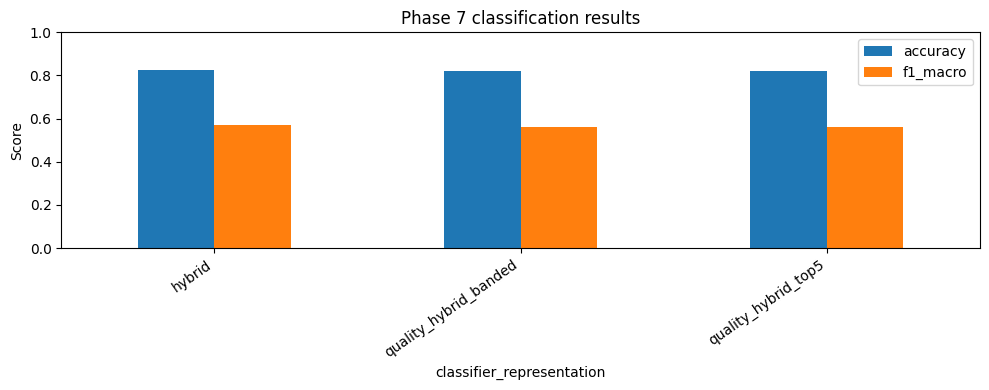

In [33]:
try:
    import matplotlib.pyplot as plt
    HAS_PLOTS = True
except Exception:
    HAS_PLOTS = False
results_path = OUTPUT_DIR / "results_table_phase7.csv"
if results_path.exists():
    results_df = pd.read_csv(results_path).sort_values(["accuracy", "f1_macro"], ascending=False)
    display(results_df)
    hybrid = results_df[results_df["classifier_representation"] == "hybrid"]
    if not hybrid.empty:
        base = hybrid.iloc[0]
        delta_df = results_df.copy()
        delta_df["delta_accuracy_vs_hybrid"] = delta_df["accuracy"] - base["accuracy"]
        delta_df["delta_macro_f1_vs_hybrid"] = delta_df["f1_macro"] - base["f1_macro"]
        display(delta_df[["classifier_representation", "accuracy", "f1_macro", "delta_accuracy_vs_hybrid", "delta_macro_f1_vs_hybrid"]])
    if HAS_PLOTS:
        ax = results_df.plot(x="classifier_representation", y=["accuracy", "f1_macro"], kind="bar", figsize=(10, 4), ylim=(0, 1))
        ax.set_title("Phase 7 classification results")
        ax.set_ylabel("Score")
        plt.xticks(rotation=35, ha="right")
        plt.tight_layout()
        plt.show()
else:
    print("No results yet:", results_path)

In [34]:
report_path = OUTPUT_DIR / "phase7_colab_report.md"
with open(report_path, "w", encoding="utf-8") as fh:
    fh.write("# Phase 7 Colab Report\n\n")
    fh.write("## Input\n\n")
    fh.write(f"Training input: `{CLASSIFY_PATH}`\n\n")
    if SUMMARY_PATH.exists():
        fh.write("## Triple Quality Summary\n\n")
        fh.write(pd.read_csv(SUMMARY_PATH).to_markdown(index=False))
        fh.write("\n\n")
    if results_path.exists():
        fh.write("## Classification Results\n\n")
        fh.write(pd.read_csv(results_path).to_markdown(index=False))
        fh.write("\n\n")
    else:
        fh.write("Classification has not been run yet.\n")
print("Report written to:", report_path)
print(report_path.read_text(encoding="utf-8")[:3000])

Report written to: /content/phase7_classification_outputs/phase7_colab_report.md
# Phase 7 Colab Report

## Input

Training input: `/content/classify_quality_combined.jsonl`

## Triple Quality Summary

| split    |   n_documents |   n_triples |   avg_triples_per_doc |   avg_quality_score |   max_quality_score |   avg_high_triples_per_doc |   avg_low_triples_per_doc |   zero_triple_documents |   high_threshold |
|:---------|--------------:|------------:|----------------------:|--------------------:|--------------------:|---------------------------:|--------------------------:|------------------------:|-----------------:|
| cluster  |          5000 |       33587 |               6.7174  |            0.769383 |            0.979671 |                     3.4678 |                   3.2496  |                      74 |             0.75 |
| classify |         10000 |       68084 |               6.8084  |            0.768498 |            0.979671 |                     3.496  |                   3